Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


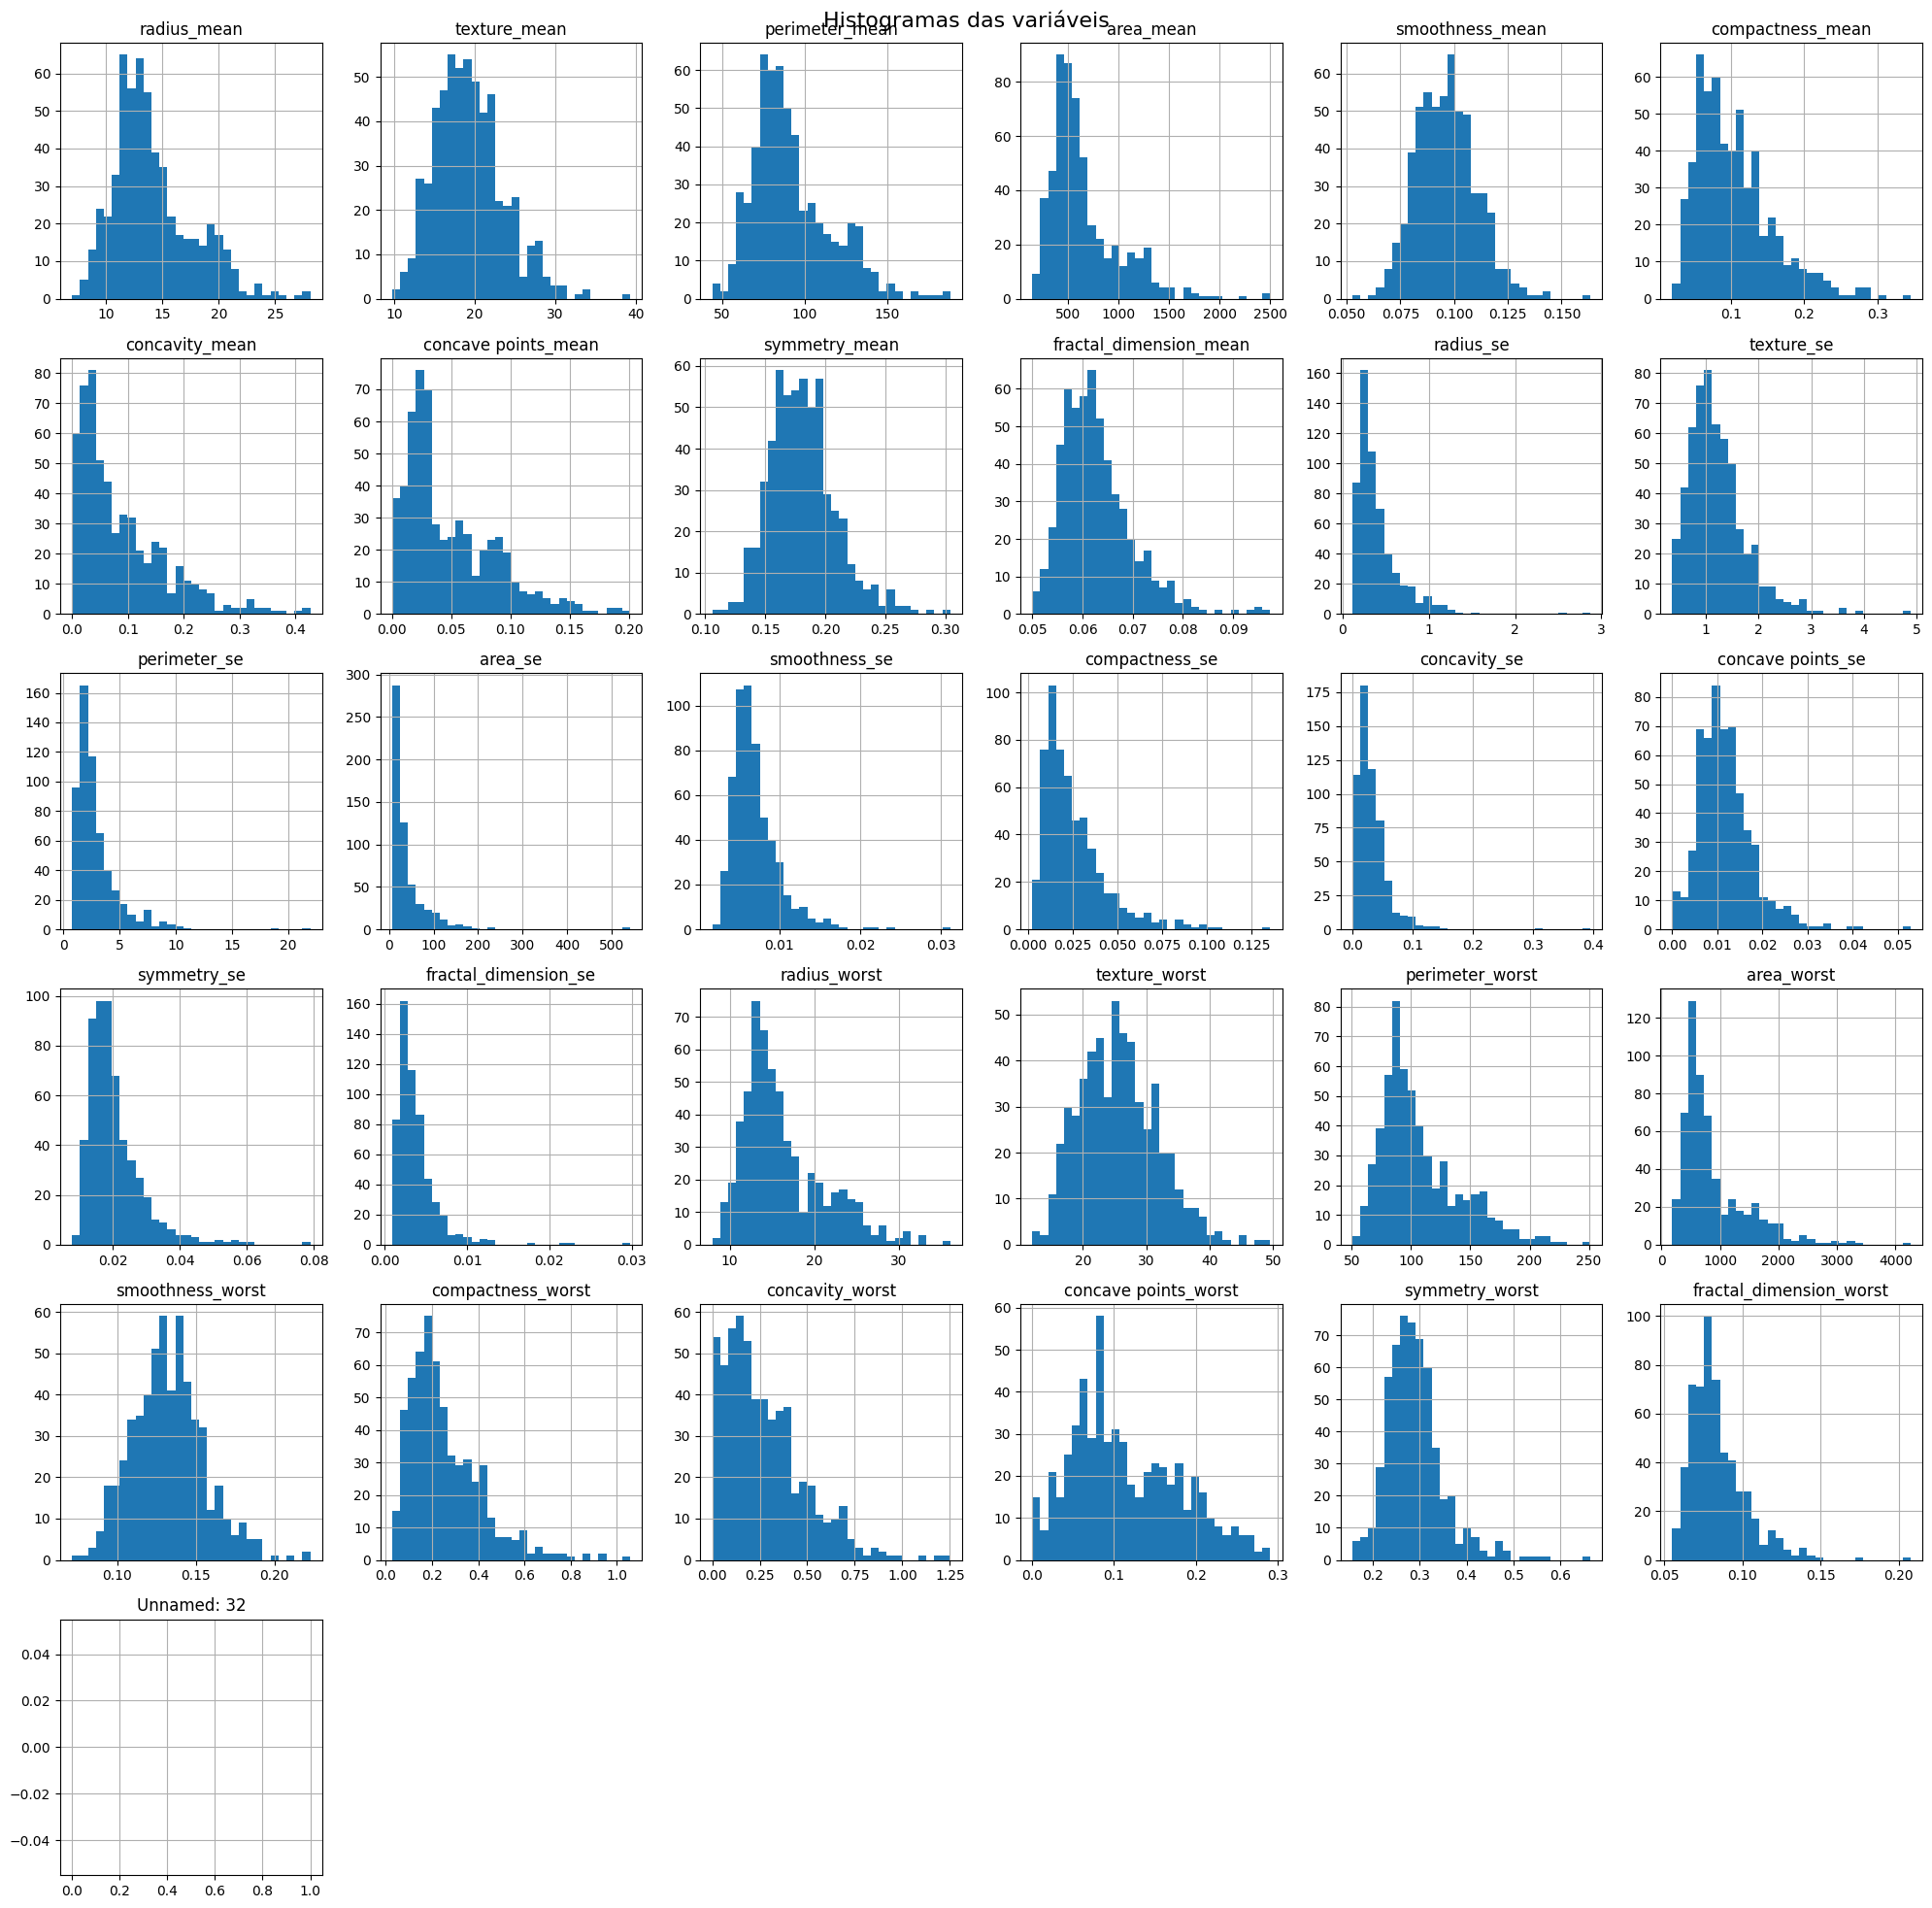

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


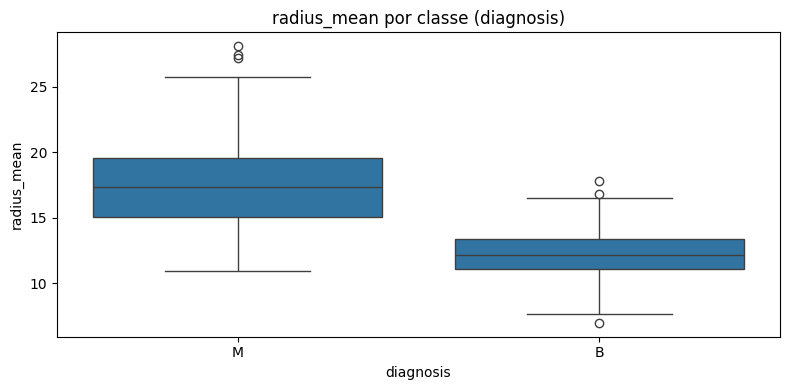

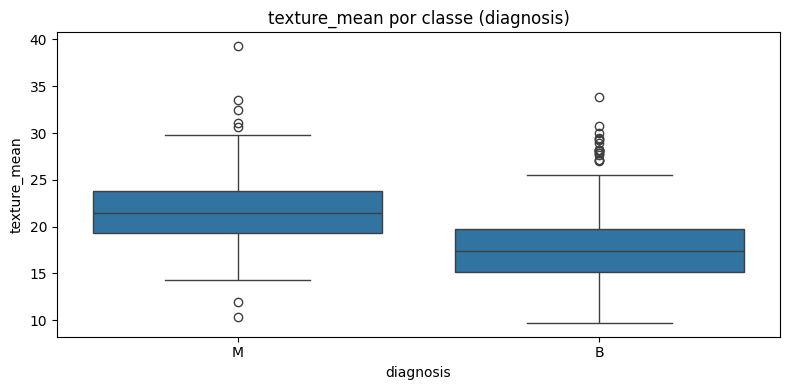

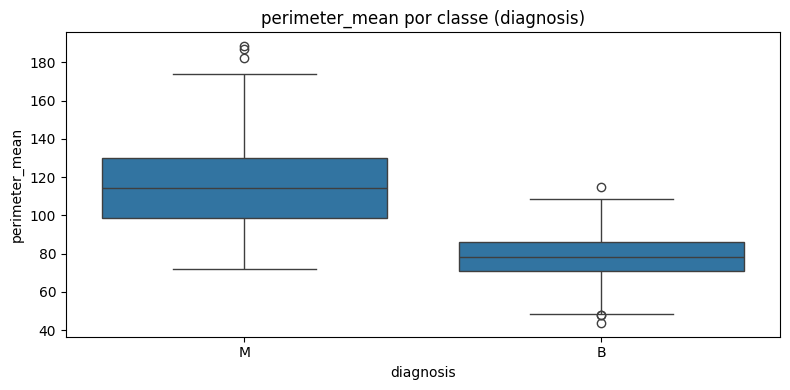

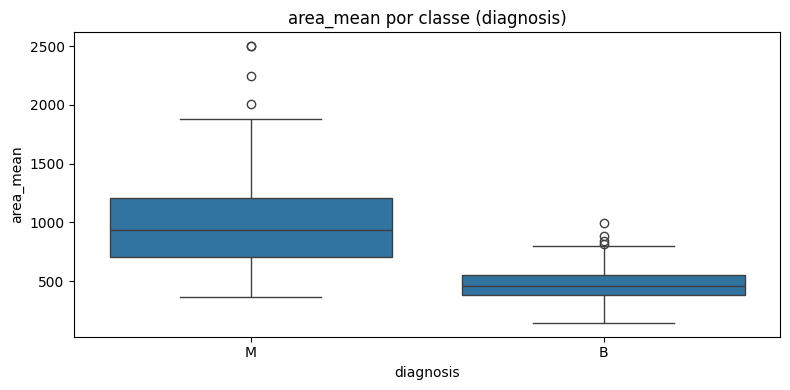

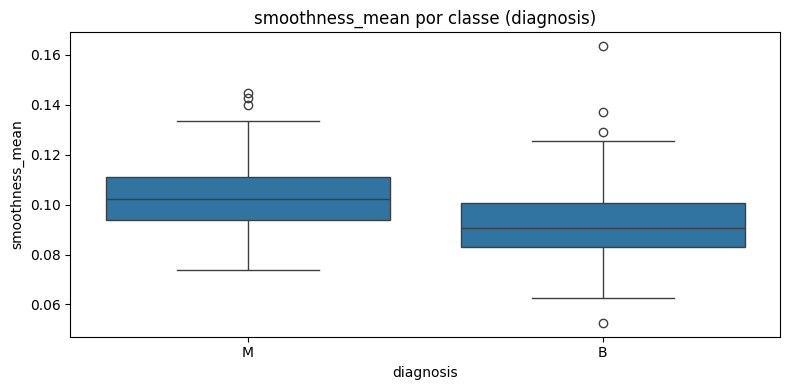

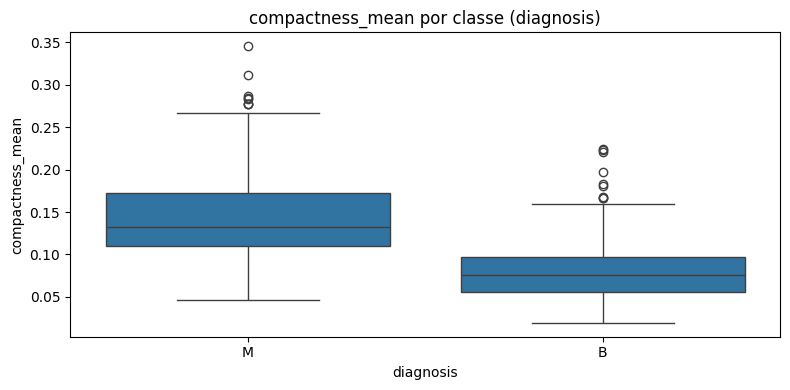

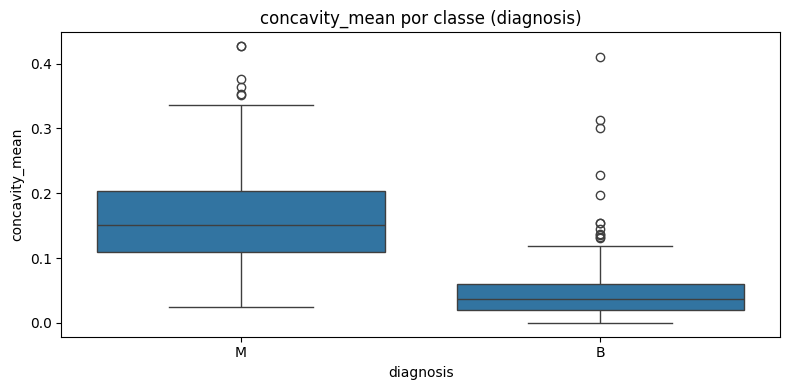

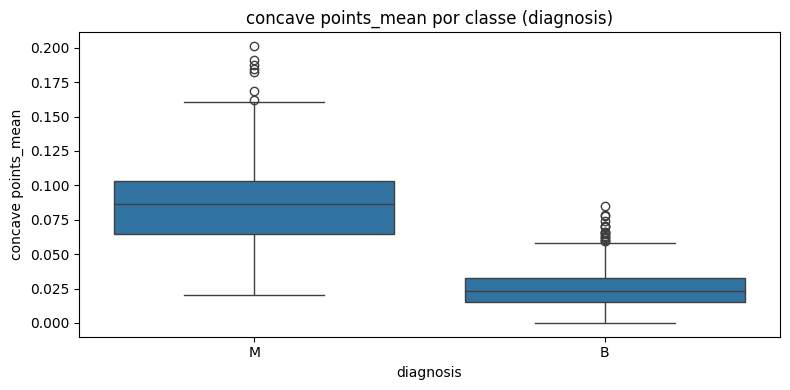

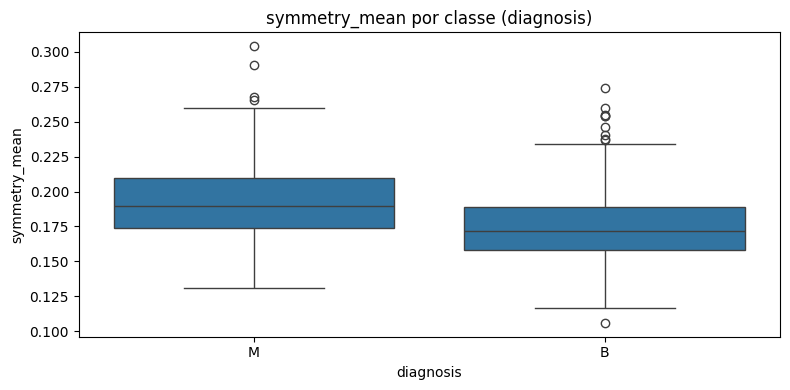

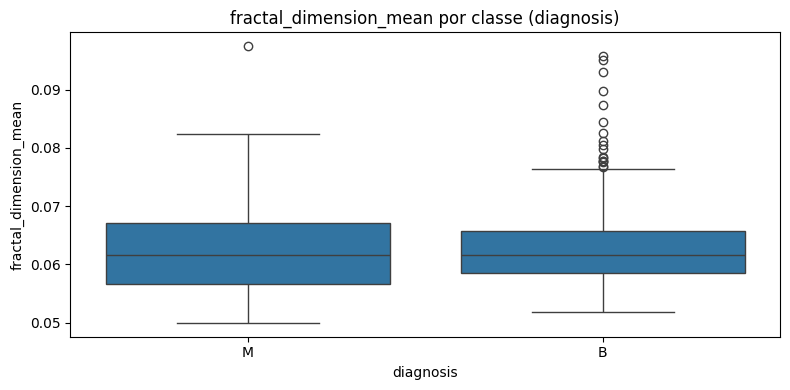

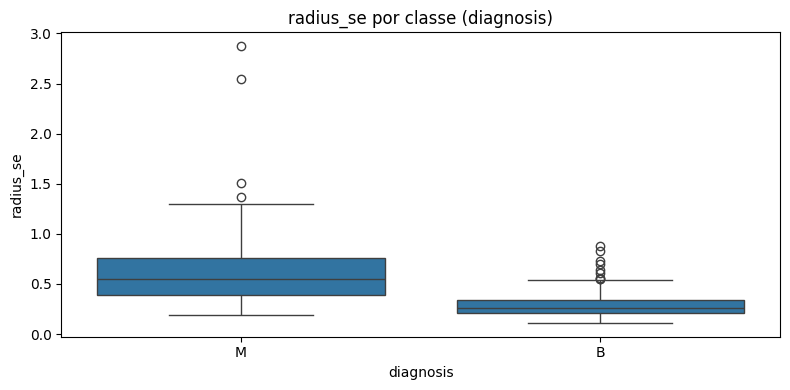

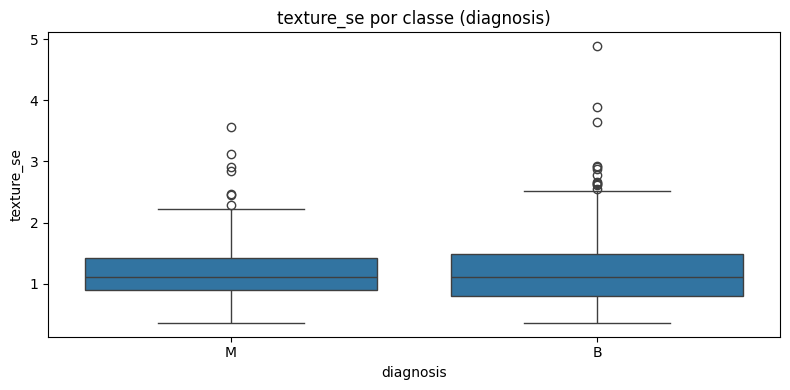

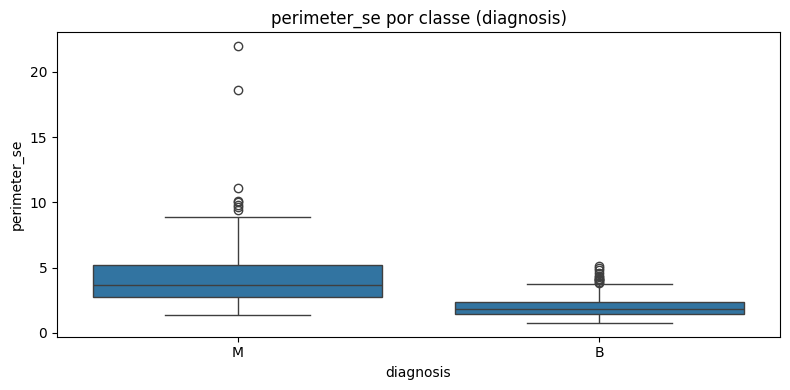

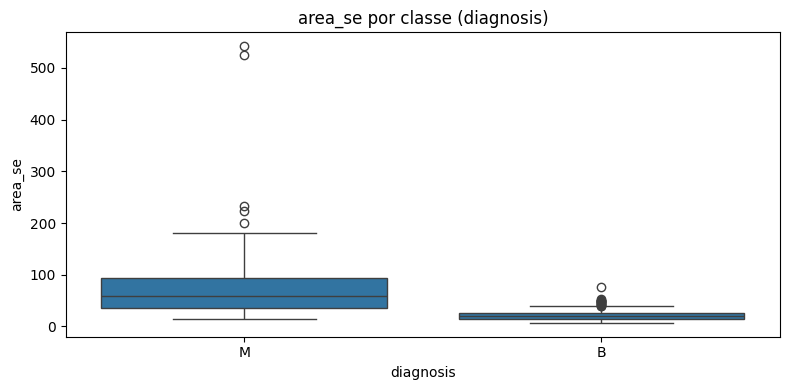

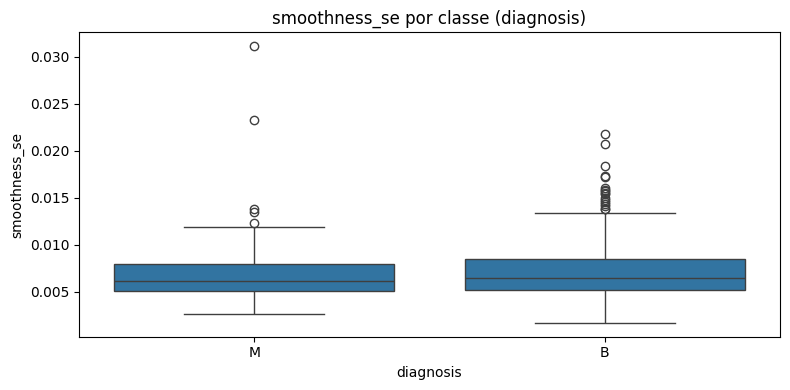

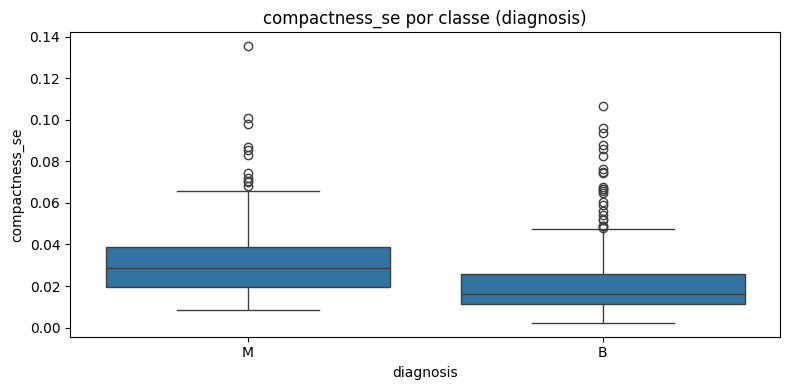

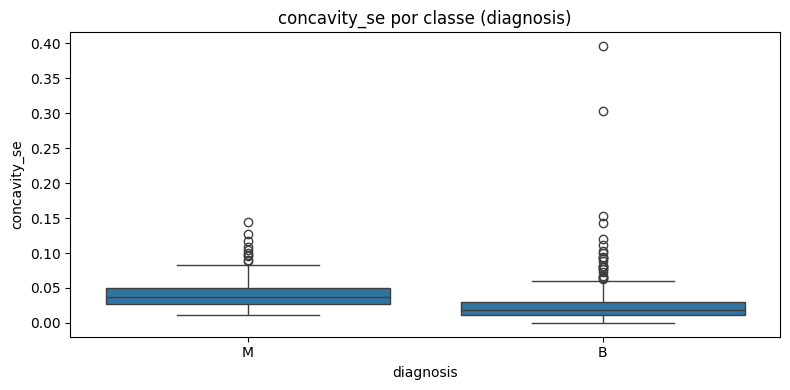

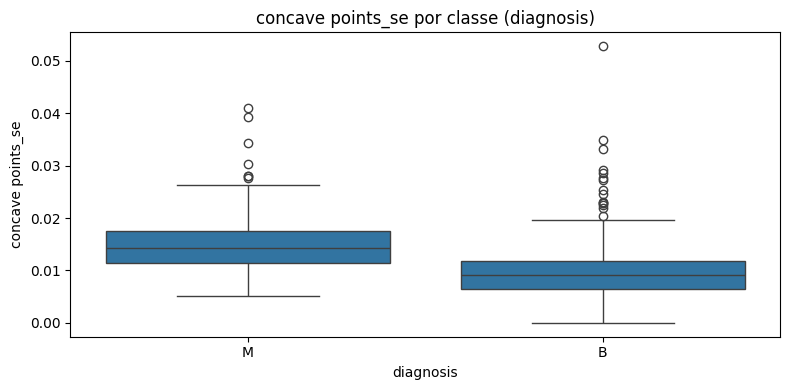

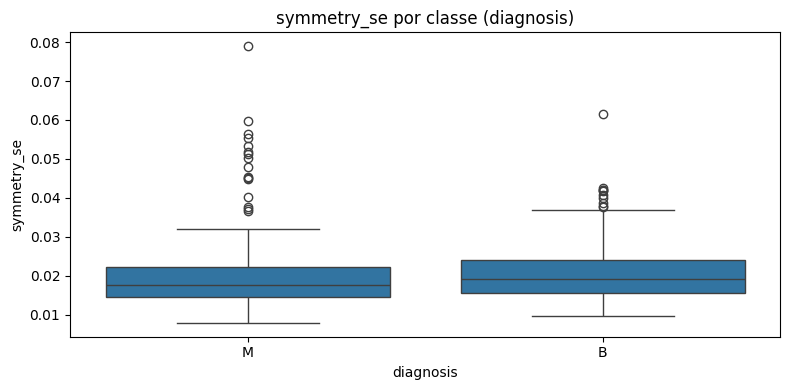

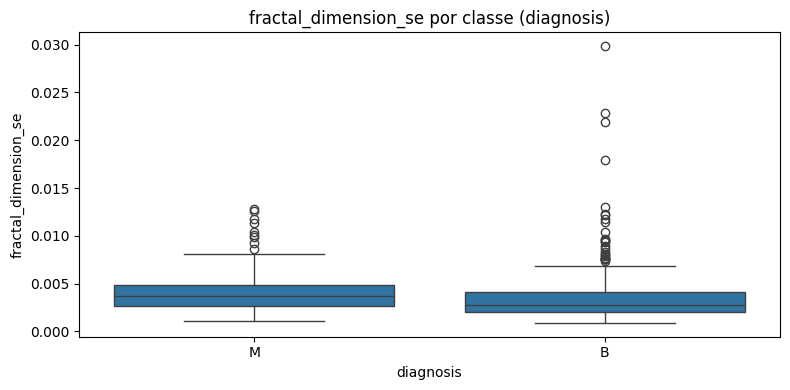

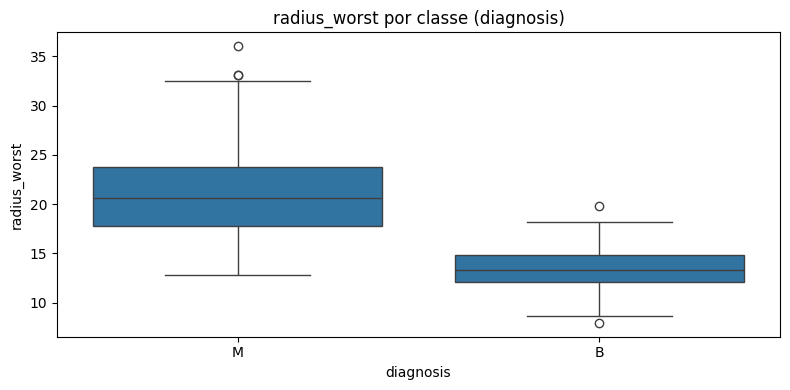

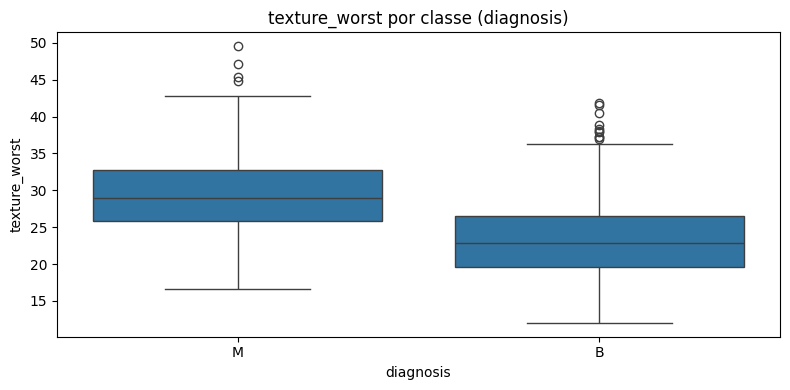

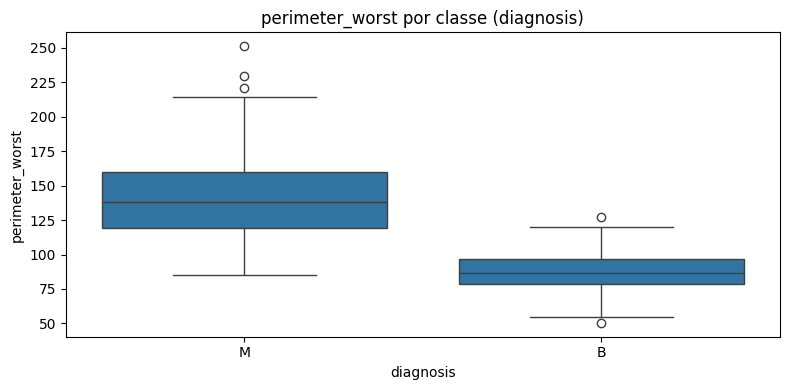

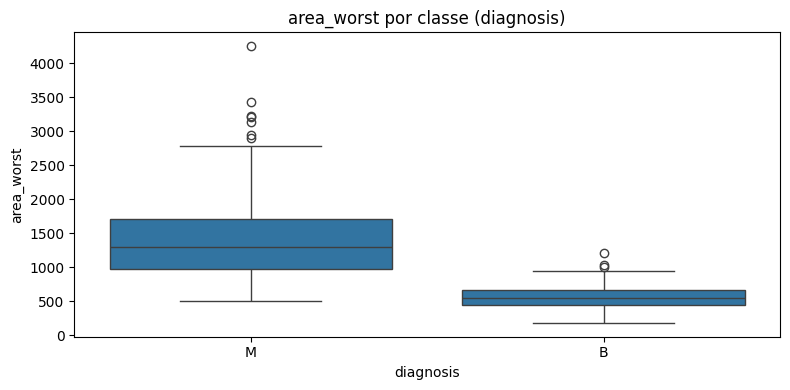

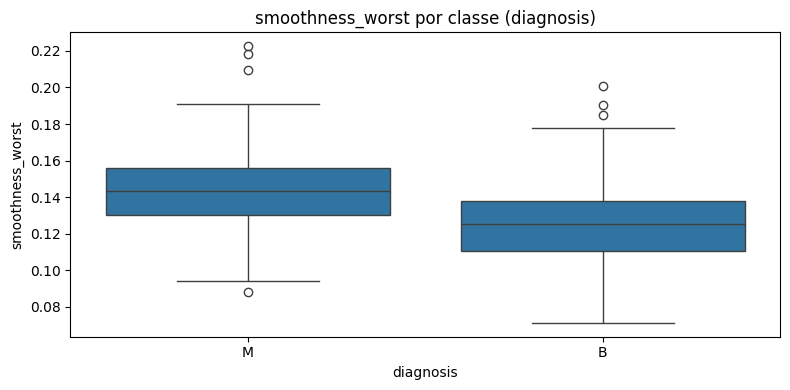

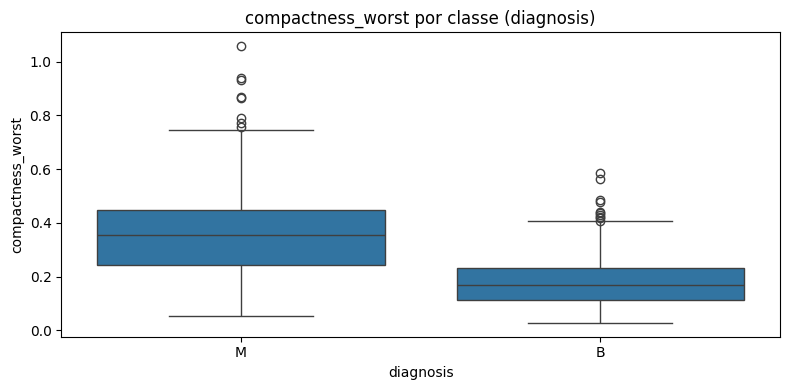

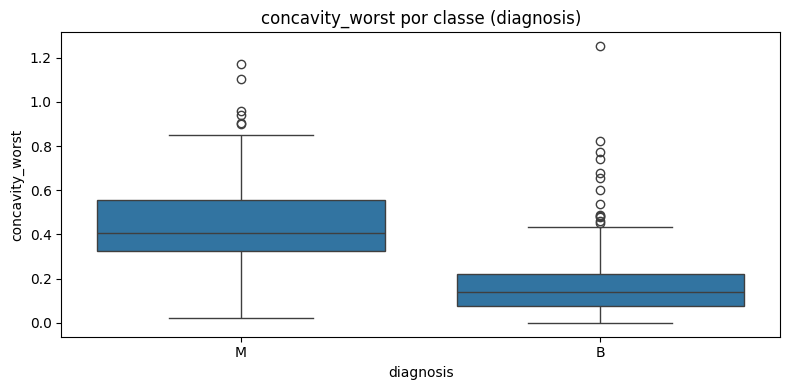

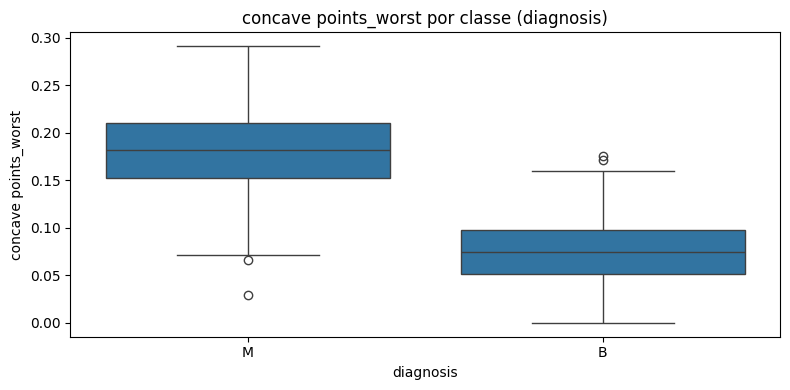

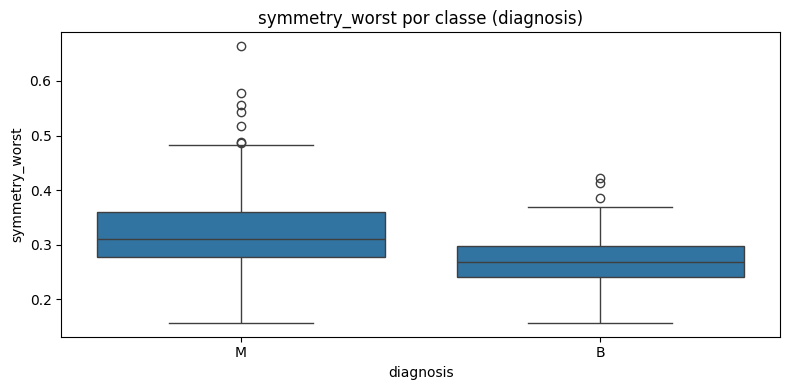

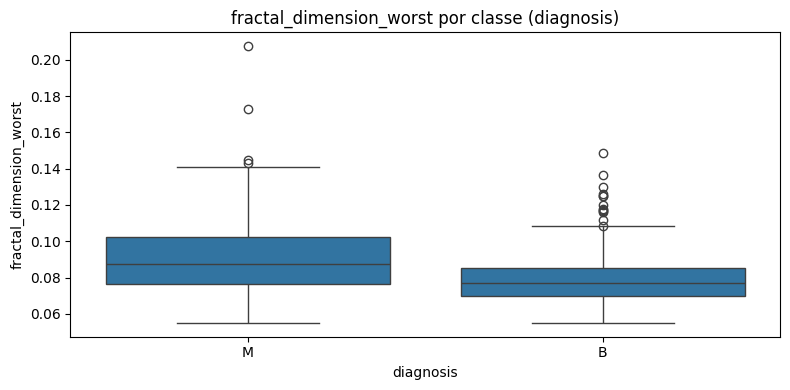

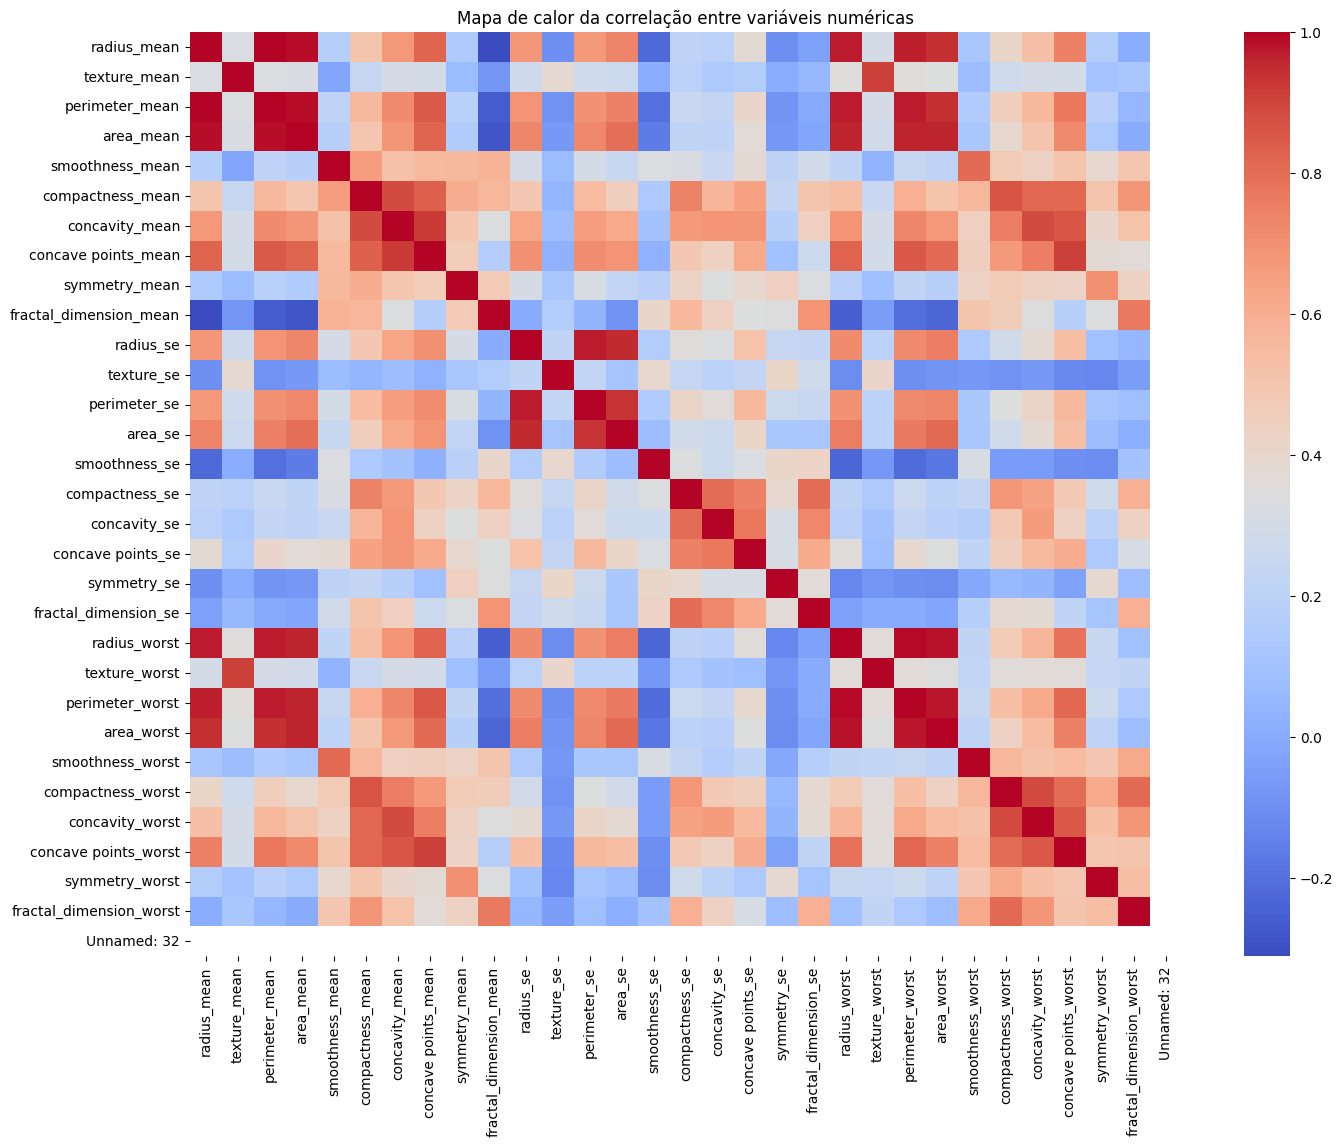

radius_mean e perimeter_mean → correlação = 0.9979
radius_worst e perimeter_worst → correlação = 0.9937
radius_mean e area_mean → correlação = 0.9874
perimeter_mean e area_mean → correlação = 0.9865
radius_worst e area_worst → correlação = 0.9840
perimeter_worst e area_worst → correlação = 0.9776
radius_se e perimeter_se → correlação = 0.9728
perimeter_mean e perimeter_worst → correlação = 0.9704
radius_mean e radius_worst → correlação = 0.9695
perimeter_mean e radius_worst → correlação = 0.9695
radius_mean e perimeter_worst → correlação = 0.9651
area_mean e radius_worst → correlação = 0.9627
area_mean e area_worst → correlação = 0.9592
area_mean e perimeter_worst → correlação = 0.9591
radius_se e area_se → correlação = 0.9518
perimeter_mean e area_worst → correlação = 0.9415
radius_mean e area_worst → correlação = 0.9411
perimeter_se e area_se → correlação = 0.9377
concavity_mean e concave points_mean → correlação = 0.9214
texture_mean e texture_worst → correlação = 0.9120
concave poi

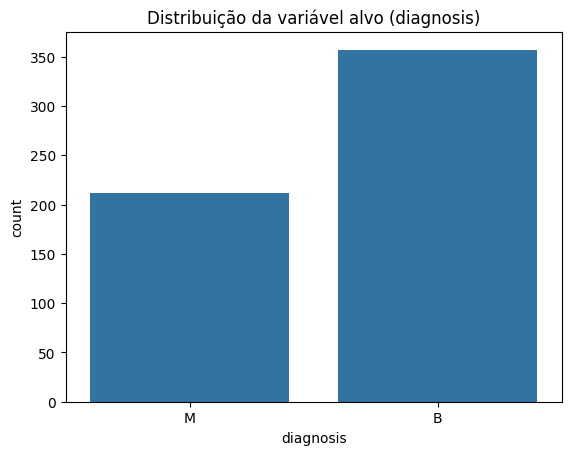

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [108]:
%pip install matplotlib
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estatísticas descritiva das variáveis usando df.describe()
df = pd.read_csv('../data/breast_cancer.csv')
df.describe()

# Histogramas individuais de cada característica

df.drop(columns=['id'], errors='ignore').hist(bins=30, figsize=(20, 20))
plt.suptitle("Histogramas das variáveis", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots por classe (análise de dispersão, outliers e comparação)

print(df.columns)


# Exclude columns with all NaN values
valid_columns = df.drop(columns=['id', 'diagnosis'], errors='ignore').dropna(axis=1, how='all').columns

for col in valid_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'{col} por classe (diagnosis)')
    plt.tight_layout()
    plt.show()

# Removendo colunas não numéricas e a 'id' (se existir)
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id'], errors='ignore')

plt.figure(figsize=(16, 12))
sns.heatmap(numerical_df.corr(), cmap='coolwarm', annot=False)
plt.title("Mapa de calor da correlação entre variáveis numéricas")
plt.show()


# Lista de pares com correlação forte (> 0.9 e < 1.0)
corr_matrix = numerical_df.corr().abs()  
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, corr_value))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: -x[2])

for pair in high_corr_pairs:
    print(f"{pair[0]} e {pair[1]} → correlação = {pair[2]:.4f}")


# Verificação da distribuição das classes alvo

sns.countplot(x='diagnosis', data=df)
plt.title("Distribuição da variável alvo (diagnosis)")
plt.show()

# Percentual
print(df['diagnosis'].value_counts(normalize=True) * 100)



# Discussão sobre possíveis variáveis redundantes ou fortemente correlacionadas.

# Com base na matriz de correlação, observou-se que algumas variáveis apresentam alta correlação linear entre si (coeficientes superiores a 0.9). Exemplos notáveis incluem:

# radius_mean com perimeter_mean e area_mean;

# perimeter_worst com radius_worst e area_worst;

# concavity_mean com concave points_mean.

# Essas correlações indicam que essas variáveis carregam informações similares e, portanto, são candidatas à remoção ou redução de dimensionalidade (ex: PCA) para evitar redundância e multicolinearidade em etapas posteriores.

# Além disso, a análise do Fator de Inflação da Variância (VIF) reforçou essa conclusão. Variáveis como:

# radius_mean,

# perimeter_mean,

# area_mean,

# radius_worst,

# apresentaram VIFs significativamente elevados (acima de 10), confirmando a presença de multicolinearidade severa.

# Portanto, é recomendado avaliar a eliminação ou agregação de variáveis altamente correlacionadas antes da modelagem preditiva.

In [109]:
%pip install torch torchvision torchaudio

# Bibliotecas do PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Pré-processamento e avaliação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Utilidades e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

Note: you may need to restart the kernel to use updated packages.


In [110]:
# Codifica a variável 'diagnosis': M = 1 (maligno), B = 0 (benigno)
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

# Separa atributos (features) e rótulo (target)
X = df.drop(columns=['id', 'diagnosis'], errors='ignore')
y = df['diagnosis']

# Normaliza os dados com média 0 e desvio padrão 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Converte para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [111]:
# Define a arquitetura da rede neural
class NeuralNet(nn.Module):
    def __init__(self, input_dim, n_layers, n_neurons, activation_fn):
        super(NeuralNet, self).__init__()
        self.layers = nn.ModuleList()
        
        # Primeira camada oculta conectada à entrada
        self.layers.append(nn.Linear(input_dim, n_neurons))
        
        # Camadas ocultas adicionais
        for _ in range(n_layers - 1):
            self.layers.append(nn.Linear(n_neurons, n_neurons))
        
        # Camada de saída: 1 neurônio para classificação binária
        self.output_layer = nn.Linear(n_neurons, 1)
        self.activation_fn = activation_fn
    
    def forward(self, x):
        for layer in self.layers:
            x = self.activation_fn(layer(x))
        return self.output_layer(x)  # não use sigmoid aqui!



In [ ]:
# Função para treinar o modelo e registrar o histórico de perda
def train_model(model, train_loader, test_loader, optimizer, criterion, n_epochs):
    history = {'loss': [], 'val_loss': []}
    
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()               # Zera gradientes
            output = model(X_batch)             # Forward pass
            loss = criterion(output, y_batch)   # Cálculo da perda
            loss.backward()                     # Backpropagation
            optimizer.step()                    # Atualiza pesos
            running_loss += loss.item()
        
        history['loss'].append(running_loss / len(train_loader))
        
        # Avaliação no conjunto de validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                val_loss += criterion(output, y_batch).item()
        history['val_loss'].append(val_loss / len(test_loader))
        
    return history


In [113]:
# Define os valores possíveis de cada hiperparâmetro
param_grid = {
    'n_layers': [1, 2],
    'n_neurons': [32, 64, 128],
    'learning_rate': [0.001, 0.01],
    'batch_size': [16, 32],
    'epochs': [100]
}

# Gera todas as combinações possíveis dos hiperparâmetros
grid = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())  # Nome dos hiperparâmetros para referência


In [ ]:
results = []  # Lista para armazenar os resultados

# Loop para cada combinação de hiperparâmetros
for values in grid:
    # Extrai os hiperparâmetros atuais
    config = dict(zip(param_names, values))
    print(f"Treinando com: {config}")
    
    # Prepara os dados em DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

    # Ativação: sempre relu neste grid
    activation_fn = F.relu

    # Instancia o modelo
    model = NeuralNet(X_train.shape[1], config['n_layers'], config['n_neurons'], activation_fn)
    
    # Define otimizador e função de perda
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    # Calcula o peso da classe positiva (malignos)
    neg = (y_train_tensor == 0).sum()
    pos = (y_train_tensor == 1).sum()
    # Corrige o pos_weight e move para mesmo device do modelo
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    model = NeuralNet(X_train.shape[1], config['n_layers'], config['n_neurons'], activation_fn).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


    
    # Treina o modelo
    history = train_model(model, train_loader, test_loader, optimizer, criterion, config['epochs'])
    
    # Avalia no conjunto de teste
    model.eval()
    with torch.no_grad():
        y_pred_logits = best_model(X_test_tensor.to(device))
        y_pred_prob = torch.sigmoid(y_pred_logits)
        y_pred = (y_pred_prob > 0.5).float()

    # Calcula métricas
    acc = accuracy_score(y_test_tensor, y_pred)
    prec = precision_score(y_test_tensor, y_pred)
    rec = recall_score(y_test_tensor, y_pred)
    f1 = f1_score(y_test_tensor, y_pred)
    params = sum(p.numel() for p in model.parameters())

    # Armazena tudo
    results.append({
        'config': config,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'params': params,
        'history': history,
    })


Treinando com: {'n_layers': 1, 'n_neurons': 32, 'learning_rate': 0.001, 'batch_size': 16, 'epochs': 100}


/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Treinando com: {'n_layers': 1, 'n_neurons': 32, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}


/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Treinando com: {'n_layers': 1, 'n_neurons': 32, 'learning_rate': 0.01, 'batch_size': 16, 'epochs': 100}


...

/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Treinando com: {'n_layers': 2, 'n_neurons': 128, 'learning_rate': 0.01, 'batch_size': 16, 'epochs': 100}


/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Treinando com: {'n_layers': 2, 'n_neurons': 128, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 100}


/home/jx/Documentos/dev/uerj/redes-neurais/breast-cancer-neural-networks/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Melhor configuração encontrada:
{'n_layers': 1, 'n_neurons': 32, 'learning_rate': 0.001, 'batch_size': 16, 'epochs': 100}
Acurácia: 0.6228
Precisão: 0.0000
Recall: 0.0000
F1-score: 0.0000
Número total de parâmetros: 1057


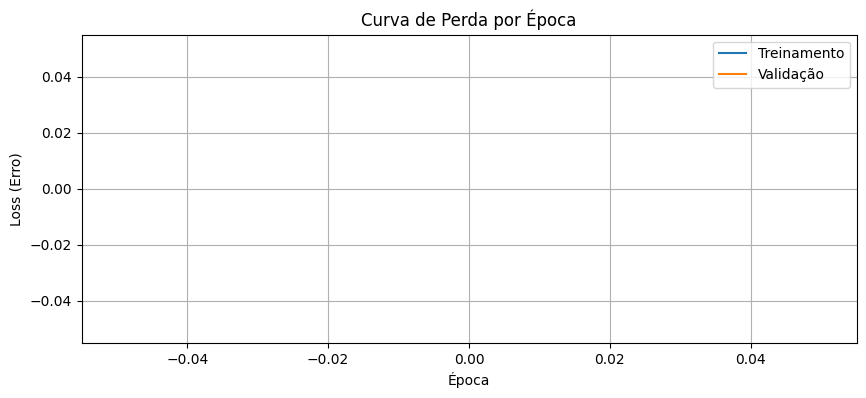

In [115]:
# Ordena os modelos pelo F1-score (ou você pode usar accuracy)
best_result = sorted(results, key=lambda x: x['f1_score'], reverse=True)[0]

print("Melhor configuração encontrada:")
print(best_result['config'])
print(f"Acurácia: {best_result['accuracy']:.4f}")
print(f"Precisão: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")
print(f"F1-score: {best_result['f1_score']:.4f}")
print(f"Número total de parâmetros: {best_result['params']}")

# Gráfico de loss (erro) por época
plt.figure(figsize=(10, 4))
plt.plot(best_result['history']['loss'], label='Treinamento')
plt.plot(best_result['history']['val_loss'], label='Validação')
plt.title("Curva de Perda por Época")
plt.xlabel("Época")
plt.ylabel("Loss (Erro)")
plt.legend()
plt.grid(True)
plt.show()


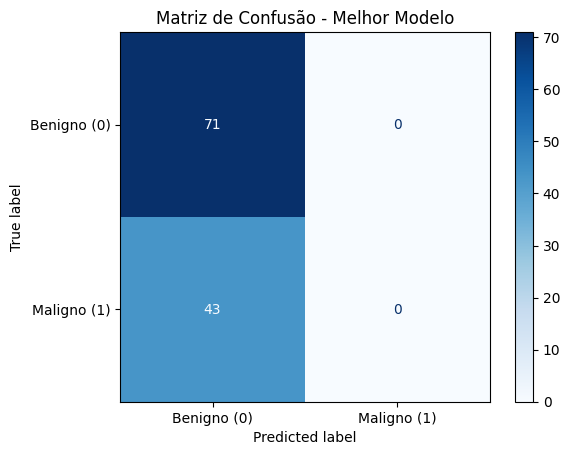

In [116]:
from sklearn.metrics import ConfusionMatrixDisplay

# Configurações do melhor modelo
best_model_config = best_result['config']
activation_fn = F.relu
best_model = NeuralNet(
    X_train.shape[1],
    best_model_config['n_layers'],
    best_model_config['n_neurons'],
    activation_fn
)

optimizer = optim.Adam(best_model.parameters(), lr=best_model_config['learning_rate'])

# CORRETO: usar BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=best_model_config['batch_size'], shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=best_model_config['batch_size'], shuffle=False)

# Treina o modelo novamente
train_model(best_model, train_loader, test_loader, optimizer, criterion, best_model_config['epochs'])

# Predições
best_model.eval()
with torch.no_grad():
    y_pred_logits = best_model(X_test_tensor)
    y_pred_prob = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred_prob > 0.5).float()

# Matriz de confusão
cm = confusion_matrix(y_test_tensor, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (0)', 'Maligno (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Melhor Modelo")
plt.grid(False)
plt.show()


In [117]:
# Cria DataFrame para visualizar comparações
results_df = pd.DataFrame([{
    'Camadas': r['config']['n_layers'],
    'Neurônios': r['config']['n_neurons'],
    'LR': r['config']['learning_rate'],
    'Batch': r['config']['batch_size'],
    'Épocas': r['config']['epochs'],
    'Acurácia': r['accuracy'],
    'Precisão': r['precision'],
    'Recall': r['recall'],
    'F1': r['f1_score'],
    'Parâmetros': r['params']
} for r in results])

# Commenting out the ace_tools import and usage since the module is not found
# import ace_tools as tools; tools.display_dataframe_to_user(name="Comparação de Modelos", dataframe=results_df)

# Display the DataFrame directly as a workaround
from IPython.display import display
display(results_df)


,Camadas,Neurônios,LR,Batch,Épocas,Acurácia,Precisão,Recall,F1,Parâmetros
0,1,32,0.001,16,100,0.622807,0.0,0.0,0.0,1057
1,1,32,0.001,32,100,0.622807,0.0,0.0,0.0,1057
2,1,32,0.010,16,100,0.622807,0.0,0.0,0.0,1057
3,1,32,0.010,32,100,0.622807,0.0,0.0,0.0,1057
4,1,64,0.001,16,100,0.622807,0.0,0.0,0.0,2113
5,1,64,0.001,32,100,0.622807,0.0,0.0,0.0,2113
6,1,64,0.010,16,100,0.622807,0.0,0.0,0.0,2113
7,1,64,0.010,32,100,0.622807,0.0,0.0,0.0,2113
8,1,128,0.001,16,100,0.622807,0.0,0.0,0.0,4225
9,1,128,0.001,32,100,0.622807,0.0,0.0,0.0,4225


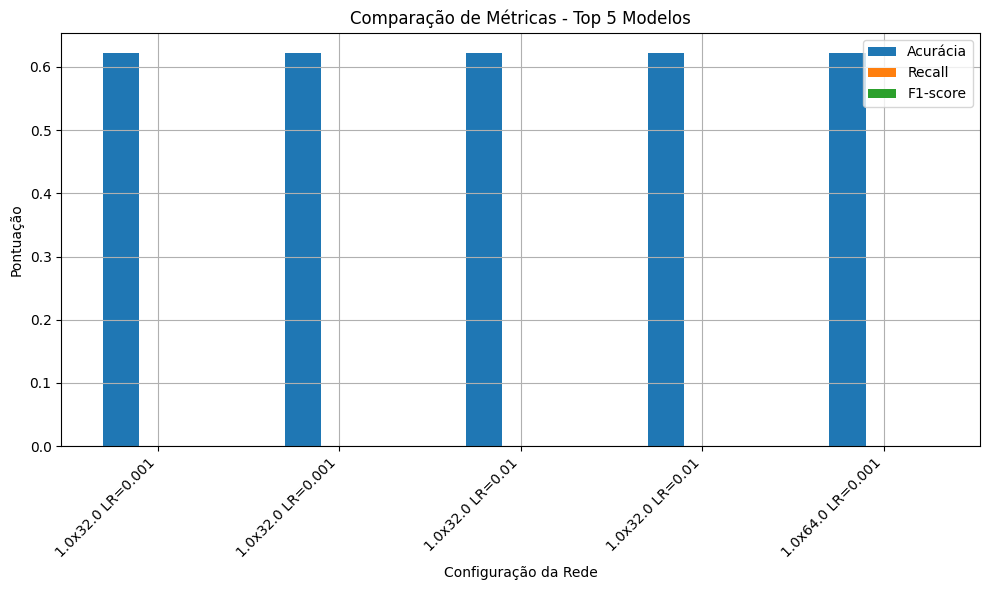

In [118]:
# Seleciona os 5 melhores modelos por F1 para visualização
top_results = results_df.sort_values(by='F1', ascending=False).head(5)

# Plota métricas
plt.figure(figsize=(10, 6))
x_labels = [f"{row['Camadas']}x{row['Neurônios']} LR={row['LR']}" for _, row in top_results.iterrows()]
x = np.arange(len(top_results))

bar_width = 0.2

plt.bar(x - bar_width, top_results['Acurácia'], width=bar_width, label='Acurácia')
plt.bar(x, top_results['Recall'], width=bar_width, label='Recall')
plt.bar(x + bar_width, top_results['F1'], width=bar_width, label='F1-score')

plt.xticks(x, x_labels, rotation=45, ha='right')
plt.title("Comparação de Métricas - Top 5 Modelos")
plt.ylabel("Pontuação")
plt.xlabel("Configuração da Rede")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()
